In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

### Part A

In [8]:
def simulation_single(T, rho=0.5, alpha=[0.5, 1], delta=[0.5, -0.5], gamma=[0.5, 1], beta=[-0.5, 0, 0]):
    
    # Initialize separate arrays for each variable
    x = np.zeros(T)
    y = np.zeros(T)
    u = np.zeros(T)
    
    # Initial lags set to zero as specified
    x_lag1 = 0.0
    x_lag2 = 0.0
    u_lag1 = 0.0    # not specified?
    
    # Simulate time series
    for t in range(T):
        # Generate random shocks at each time period, though not specified?
        wt = np.random.normal(0, 1)
        vt = np.random.normal(0, 1)
        
        # Equations
        u[t] = rho * u_lag1 + vt
        x[t] = alpha[0] + alpha[1] * t + delta[0] * x_lag1 + delta[1] * x_lag2 + wt
        y[t] = gamma[0] + gamma[1] * t + beta[0] * x[t] + beta[1] * x_lag1 + beta[2] * x_lag2 + u[t]
        
        # Update lags for next iteration
        x_lag2 = x_lag1
        x_lag1 = x[t]
        u_lag1 = u[t]
    
    # Construct design matrix X with intercept, time, and lags
    intercept = np.ones(T)
    time = np.arange(T)
    x_lag1_vec = np.concatenate([[0], x[:-1]])  # x_{t-1}: shift by 1
    x_lag2_vec = np.concatenate([[0, 0], x[:-2]])  # x_{t-2}: shift by 2
    
    X = np.column_stack([intercept, time, x, x_lag1_vec, x_lag2_vec])
    
    return y, X, u

def simulation_panel(S, T, rho=0.5, alpha=[0.5, 1], delta=[0.5, -0.5], gamma=[0.5, 1], beta=[-0.5, 0, 0]):
    # Initialize arrays to hold the panel data
    Y = np.zeros((S, T))
    X = np.zeros((S, T, 5))  # 5 columns: intercept, time, x_t, x_{t-1}, x_{t-2}
    U = np.zeros((S, T))
    
    for s in range(S):
        y_s, X_s, u_s = simulation_single(T, rho, alpha, delta, gamma, beta)
        Y[s, :] = y_s
        X[s, :, :] = X_s
        U[s, :] = u_s
    
    return Y, X, U

### Part B

Under the baseline parameters, this is a ............

### Part C

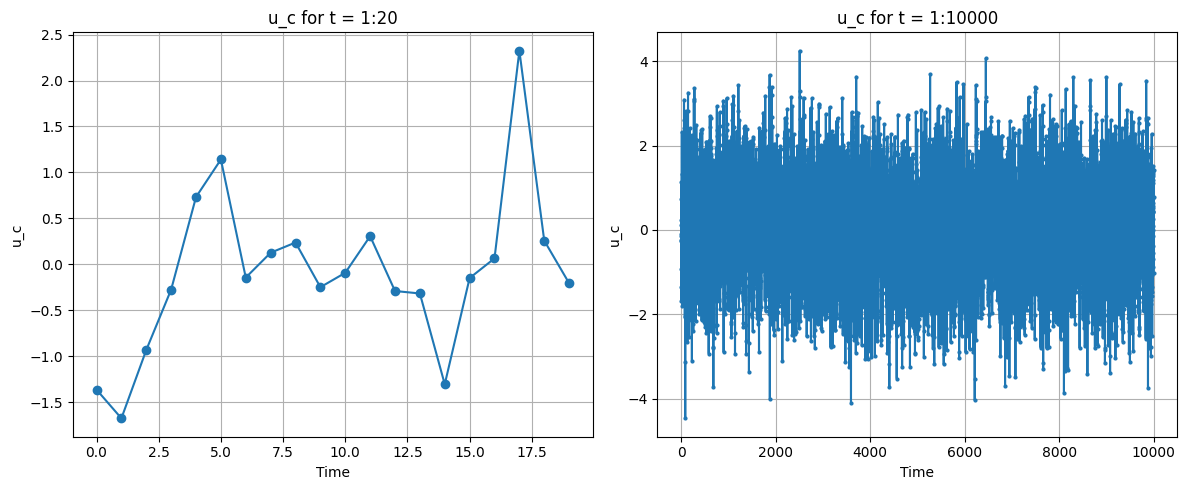

In [12]:
y_c, X_c, u_c = simulation_single(T=10000)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(u_c[:20], marker='o')
plt.title('u_c for t = 1:20')
plt.xlabel('Time')
plt.ylabel('u_c')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(u_c, marker='o', markersize=2)
plt.title('u_c for t = 1:10000')
plt.xlabel('Time')
plt.ylabel('u_c')
plt.grid()
plt.tight_layout()
plt.show()

The data does not look to be very stable from t = 1:20 but deos apear to level out around u_c = 0 over many time periods, similar to a normal function at mean = 0.

### Part D

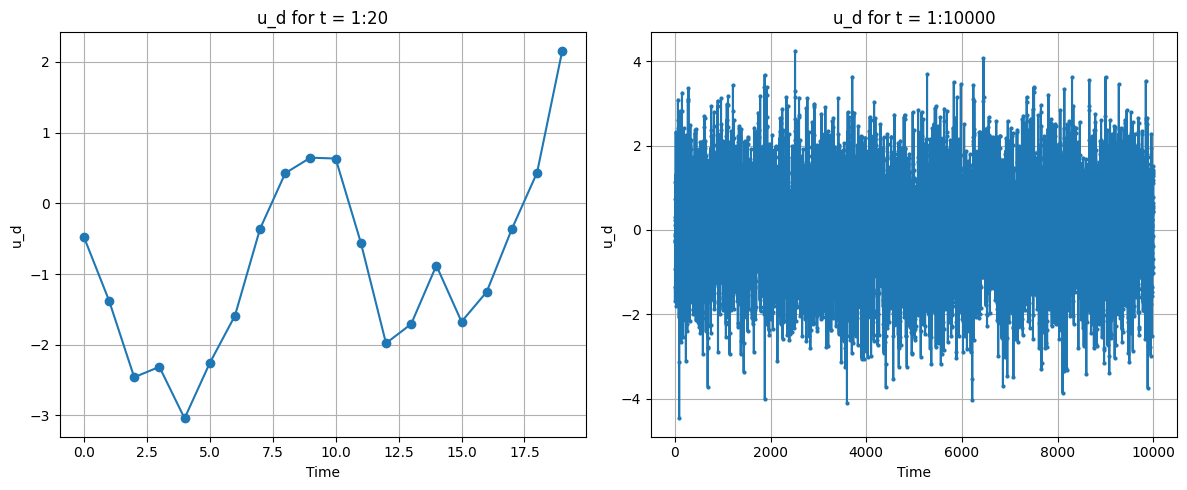

In [13]:
y_d, X_d, u_d = simulation_single(T=10000, rho=1.0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(u_d[:20], marker='o')
plt.title('u_d for t = 1:20')
plt.xlabel('Time')
plt.ylabel('u_d')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(u_c, marker='o', markersize=2)
plt.title('u_d for t = 1:10000')
plt.xlabel('Time')
plt.ylabel('u_d')
plt.grid()
plt.tight_layout()
plt.show()

### Part E

While the time series results with t = 1:10000 appears relatively the same in both c and, which is expected considering the simulation is modeled to follow a normal function in the long term, the short-term simulation t = 1:20 is different.

### Part F

In [23]:
S, T = 100, 100

Y = np.zeros((S, T))
X = np.zeros((S, T, 5))  # 5 columns: intercept, time, x_t, x_{t-1}, x_{t-2}
U = np.zeros((S, T))
estimates = np.zeros((S, 5))  # To store estimates for each simulation

for s in range(S):
    y_s, X_s, u_s = simulation_single(T)
    Y[s, :] = y_s
    X[s, :, :] = X_s
    U[s, :] = u_s

    model = sm.OLS(y_s, X_s)
    results = model.fit()
    estimates[s, :] = results.params

print("Average coefficient estimates across simulations:")
print(f"Intercept (γ0): {estimates[:, 0].mean():.4f}")
print(f"Time (γ1):      {estimates[:, 1].mean():.4f}")
print(f"x_t (β0):       {estimates[:, 2].mean():.4f}")
print(f"x_{{t-1}} (β1):   {estimates[:, 3].mean():.4f}")
print(f"x_{{t-2}} (β2):   {estimates[:, 4].mean():.4f}")

print("\nStandard deviation of estimates:")
print(f"Intercept (γ0): {estimates[:, 0].std():.4f}")
print(f"Time (γ1):      {estimates[:, 1].std():.4f}")
print(f"x_t (β0):       {estimates[:, 2].std():.4f}")
print(f"x_{{t-1}} (β1):   {estimates[:, 3].std():.4f}")
print(f"x_{{t-2}} (β2):   {estimates[:, 4].std():.4f}")

Average coefficient estimates across simulations:
Intercept (γ0): 0.4954
Time (γ1):      0.9862
x_t (β0):       -0.4998
x_{t-1} (β1):   0.0067
x_{t-2} (β2):   0.0074

Standard deviation of estimates:
Intercept (γ0): 0.3918
Time (γ1):      0.1899
x_t (β0):       0.1079
x_{t-1} (β1):   0.0936
x_{t-2} (β2):   0.1250


### Part G

In [ ]:
S, T = 100, 100

Y = np.zeros((S, T))
X = np.zeros((S, T, 5))  # 5 columns: intercept, time, x_t, x_{t-1}, x_{t-2}
U = np.zeros((S, T))
estimates = np.zeros((S, 5))  # To store estimates for each simulation

for s in range(S):
    y_s, X_s, u_s = simulation_single(T, rho=1.0)
    Y[s, :] = y_s
    X[s, :, :] = X_s
    U[s, :] = u_s

    model = sm.OLS(y_s, X_s)
    results = model.fit()
    estimates[s, :] = results.params